# Analyse des scores : Nutri-score et Éco-score

L'objectif de ce notebook est de réaliser une **Analyse Exploratoire des Données (EDA)** directement ciblée sur nos deux variables phares : le **Nutri-score** (Santé) et le **Score Environnemental / Éco-score** (Environnement).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration visuelle (esthétique)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 150)

## 1. Chargement des données filtrées

Au lieu de charger la base OpenFoodFacts tentaculaire de 12 Go, nous utilisons la version allégée que nous avons générée via Polars. Le chargement devrait être quasiment instantané en mémoire.

In [8]:
file_path = "Nutri/traité_sans_nutriscore.csv"

try:
    try:
        # Tentative de lecture standard avec détection automatique du séparateur
        df = pd.read_csv(file_path, sep=None, engine="python")
    except pd.errors.ParserError:
        # Fallback tolérant : ignore les lignes mal formées
        df = pd.read_csv(file_path, sep=None, engine="python", on_bad_lines="skip")
        print("⚠️ Certaines lignes mal formatées ont été ignorées (on_bad_lines='skip').")

    print(f"✅ Fichier chargé avec succès ! Dimensions : {df.shape[0]:,} produits, {df.shape[1]} variables.")
    display(df.head())
except FileNotFoundError:
    print(f"❌ ERREUR : Le fichier '{file_path}' n'a pas été trouvé.\nAvez-vous bien terminé l'exécution complète du carnet 'traitement_donnees_polars.ipynb' ?")

✅ Fichier chargé avec succès ! Dimensions : 0 produits, 15 variables.


,code,product_name,nova_group,additives_n,energy-kj_100g,energy-kcal_100g,sugars_100g,carbohydrates_100g,saturated-fat_100g,fat_100g,salt_100g,proteins_100g,fiber_100g,fruits-vegetables-legumes_100g,nutriscore_grade


## 1.5. Étude des valeurs manquantes (Nutri-score et Éco-score)

Maintenant que les données sont chargées, regardons combien il manque de scores (valeurs nulles / non renseignées sur les packagings).

In [9]:
total_products = len(df)

# Comptage des doublons/valeurs manquantes
missing_nutri = df['nutriscore_score'].isna().sum() if 'nutriscore_score' in df.columns else total_products
missing_eco = df['environmental_score_score'].isna().sum() if 'environmental_score_score' in df.columns else total_products

print(f"🔹 Nombre total de produits dans ce jeu de données : {total_products:,}\n")
print(f"❌ Nutri-score manquant : {missing_nutri:,} produits ({(missing_nutri/total_products)*100:.1f} %)")
print(f"❌ Éco-score manquant   : {missing_eco:,} produits ({(missing_eco/total_products)*100:.1f} %)")

# Vérification des lignes où les DEUX manquent (devrait être quasi-nul grâce au pré-filtre Polars)
if 'nutriscore_score' in df.columns and 'environmental_score_score' in df.columns:
    missing_both = df['nutriscore_score'].isna() & df['environmental_score_score'].isna()
    print(f"⚠️ Produits sans NI Nutri-score NI Éco-score : {missing_both.sum():,} ({(missing_both.sum()/total_products)*100:.1f} %)")
    
    # Représentation graphique sous forme de Bar Chart
    plt.figure(figsize=(10, 5))
    bars = plt.bar(['Nutri-score manquant', 'Éco-score manquant', 'Les deux manquants'], 
                   [missing_nutri, missing_eco, missing_both.sum()], 
                   color=['tomato', 'forestgreen', 'grey'], alpha=0.8)
    
    plt.title("Quantité de valeurs manquantes par Score", fontsize=14, pad=15)
    plt.ylabel("Nombre de produits affectés")
    
    # Ajouter les étiquettes pour les rendre plus lisibles au dessus des barres
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (total_products*0.02), f"{int(yval):,}", ha='center', va='bottom', fontweight='bold')
        
    # Limite en Y pour aérer le haut du graphique
    plt.ylim(0, max([missing_nutri, missing_eco, missing_both.sum()]) * 1.2)
    plt.show()

🔹 Nombre total de produits dans ce jeu de données : 0



ZeroDivisionError: division by zero

## 2. Analyse univariée : Les distributions des Scores
Regardons comment se répartissent le Nutri-score et l'Éco-score. Sont-ils distribués normalement ? La plupart des produits sont-ils bien ou mal notés ?

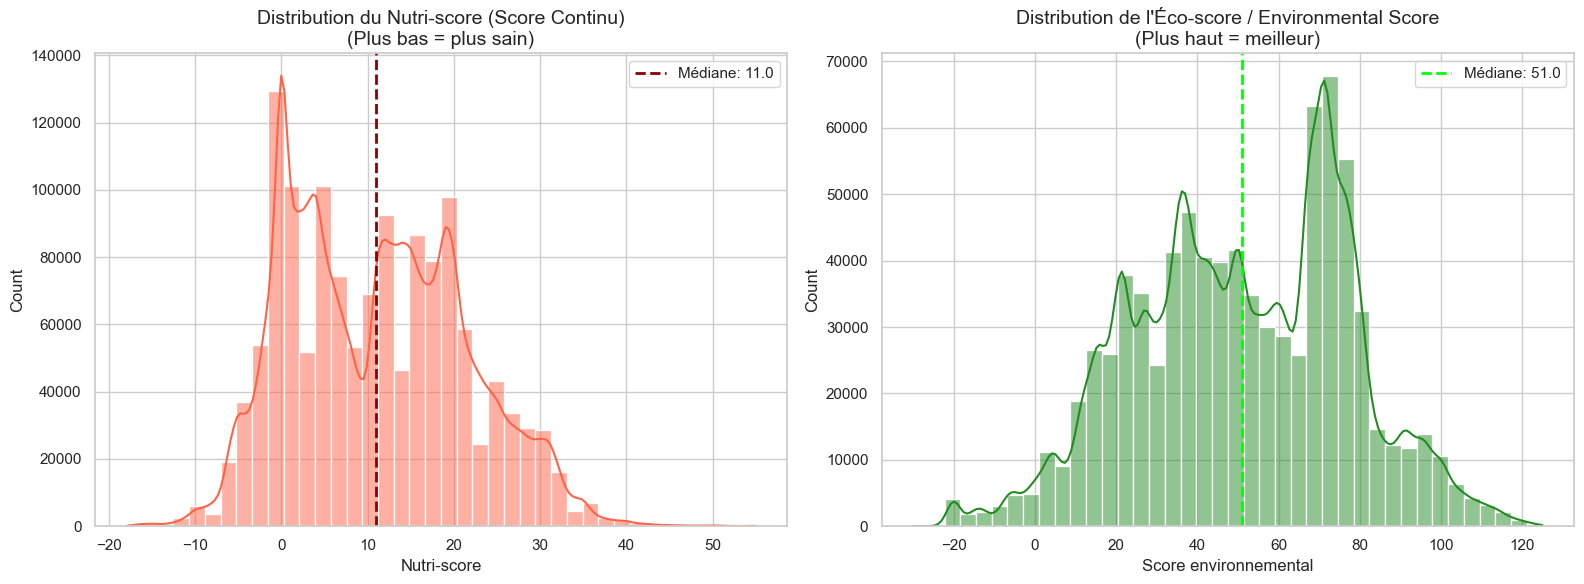

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ================== NUTRI-SCORE ==================
if 'nutriscore_score' in df.columns:
    sns.histplot(df['nutriscore_score'].dropna(), bins=40, kde=True, ax=axes[0], color='tomato')
    axes[0].set_title("Distribution du Nutri-score (Score Continu)\n(Plus bas = plus sain)", fontsize=14)
    axes[0].set_xlabel("Nutri-score")
    axes[0].axvline(df['nutriscore_score'].median(), color='darkred', linestyle='dashed', linewidth=2, label=f"Médiane: {df['nutriscore_score'].median()}")
    axes[0].legend()

# ================== ECO-SCORE ==================
if 'environmental_score_score' in df.columns:
    sns.histplot(df['environmental_score_score'].dropna(), bins=40, kde=True, ax=axes[1], color='forestgreen')
    axes[1].set_title("Distribution de l'Éco-score / Environmental Score\n(Plus haut = meilleur)", fontsize=14)
    axes[1].set_xlabel("Score environnemental")
    axes[1].axvline(df['environmental_score_score'].median(), color='lime', linestyle='dashed', linewidth=2, label=f"Médiane: {df['environmental_score_score'].median()}")
    axes[1].legend()

plt.tight_layout()
plt.show()

### Répartition par Grades Officiels (A, B, C, D, E)

Maintenant, visualisons les fréquences d'apparitions des fameuses *lettres* colorées souvent apposées sur les packagings.

C:\Users\Gambey\AppData\Local\Temp\ipykernel_15888\2687822099.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='nutriscore_grade', order=grade_order, palette=pal_nutri, ax=axes[0])
C:\Users\Gambey\AppData\Local\Temp\ipykernel_15888\2687822099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='environmental_score_grade', order=grade_order, palette='RdYlGn_r', ax=axes[1])


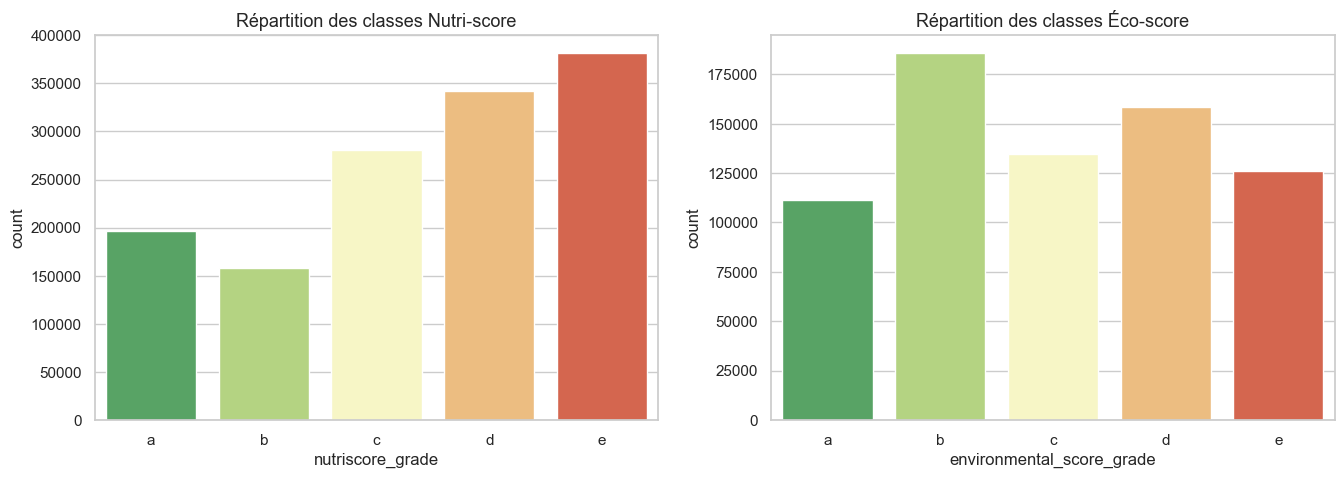

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
grade_order = ['a', 'b', 'c', 'd', 'e']
pal_nutri = sns.color_palette("RdYlGn_r", 5)

if 'nutriscore_grade' in df.columns:
    sns.countplot(data=df, x='nutriscore_grade', order=grade_order, palette=pal_nutri, ax=axes[0])
    axes[0].set_title("Répartition des classes Nutri-score", fontsize=13)
    
if 'environmental_score_grade' in df.columns:
    sns.countplot(data=df, x='environmental_score_grade', order=grade_order, palette='RdYlGn_r', ax=axes[1])
    axes[1].set_title("Répartition des classes Éco-score", fontsize=13)

plt.show()

## 3. Corrélations : Qu'est-ce qui définit le Nutri-score ?

En nutrition, le score final découle d'un équilibre entre *nutriments à limiter* (énergie, acides gras saturés, sucres simples, sel) et *nutriments à privilégier* (fibres, protéines, part de fruits/légumes). Observons la signature de cette corrélation.

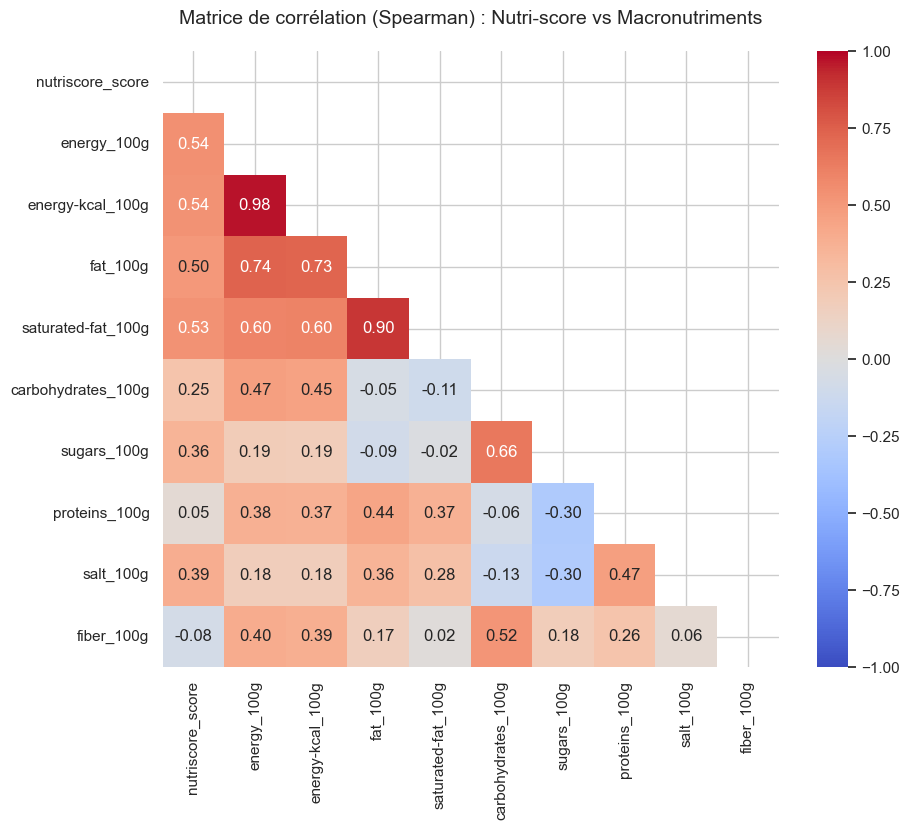

In [ ]:
# On s'intéresse particulièrement aux macronutriments centraux
key_nutrients = [
    'energy_100g', 'energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
    'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'fiber_100g'
]
# Vérifier l'intersection (% de g qui existent bien pour éviter les Crashs)
key_nutrients = [c for c in key_nutrients if c in df.columns]

cols_to_correlate = ['nutriscore_score'] + key_nutrients

if 'nutriscore_score' in df.columns:
    # Corrélation de Spearman (plus résistante aux valeurs aberrantes par rapport à Pearson)
    corr_matrix = df[cols_to_correlate].corr(method='spearman')
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, annot=True, cmap='coolwarm', 
        vmin=-1, vmax=1, fmt=".2f", square=True, 
        mask=np.triu(np.ones_like(corr_matrix, dtype=bool)) # Cacher la diagonale supérieure
    )
    plt.title("Matrice de corrélation (Spearman) : Nutri-score vs Macronutriments", fontsize=14, pad=20)
    plt.show()

> **Interprétation :** Une corrélation fortement **positive** avec `nutriscore_score` signifie que cet élément **détériore** la note (ex: Sucre, Sel). Une corrélation **négative** (ex: Protéines, Fibres) signifie qu'il a tendance à la **bonifier**.

## 4. Focus sur l'Éco-score (Environnement)

Le score environnemental, basé sur l'Analyse du Cycle de Vie (ACV), dépend logiquement des processus industriels, de l'origine de la matière première ou des additifs de synthèse.\nMesurons ici l'impact du **Nova Group** (la transformation) et du **nombre d'additifs**.

C:\Users\Gambey\AppData\Local\Temp\ipykernel_15888\4067786462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Gambey\AppData\Local\Temp\ipykernel_15888\4067786462.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


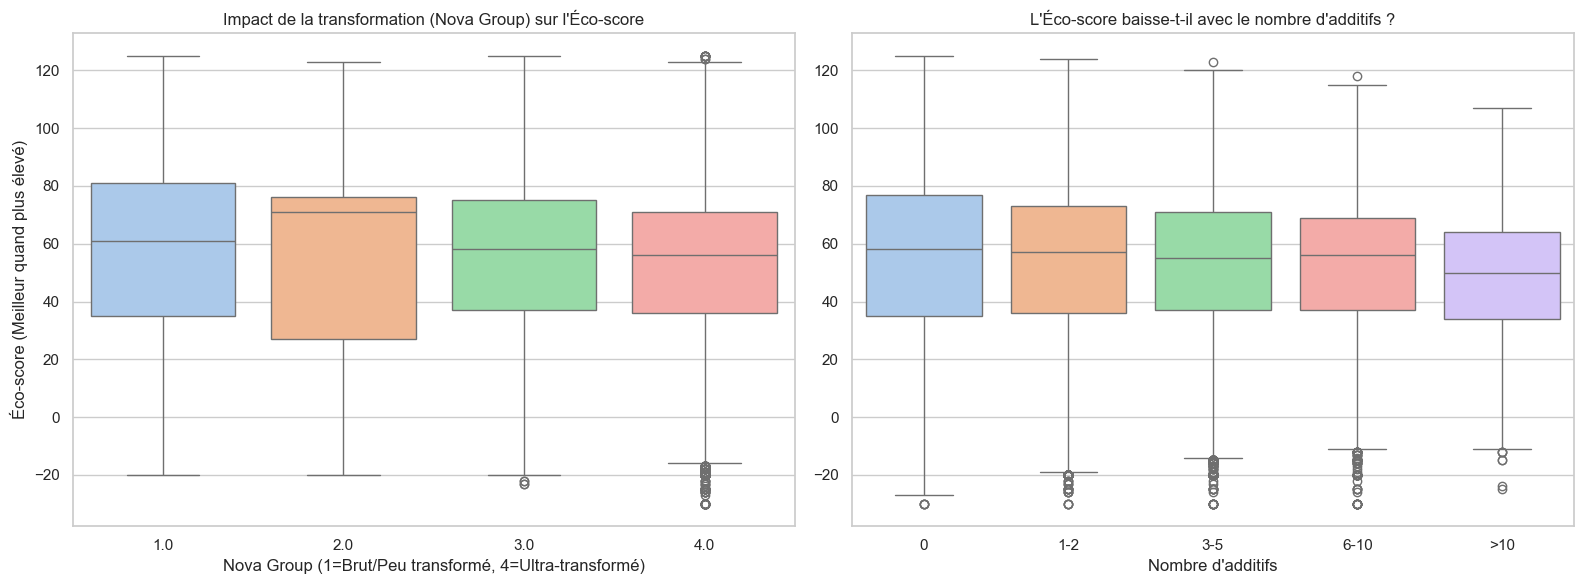

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ----------------- NOVA GROUP -----------------
if 'nova_group' in df.columns and 'environmental_score_score' in df.columns:
    # On retire les Nova Group vides
    df_nova = df.dropna(subset=['nova_group', 'environmental_score_score'])
    sns.boxplot(
        data=df_nova, 
        x='nova_group', y='environmental_score_score', 
        ax=axes[0], palette='pastel'
    )
    axes[0].set_title("Impact de la transformation (Nova Group) sur l'Éco-score")
    axes[0].set_xlabel("Nova Group (1=Brut/Peu transformé, 4=Ultra-transformé)")
    axes[0].set_ylabel("Éco-score (Meilleur quand plus élevé)")

# ----------------- ADDITIFS -----------------
if 'additives_n' in df.columns and 'environmental_score_score' in df.columns:
    # Discrétisation en catégories pour le boxplot (0,,1-2..)
    df['additifs_cat'] = pd.cut(
        df['additives_n'], 
        bins=[-1, 0, 2, 5, 10, 100], 
        labels=['0', '1-2', '3-5', '6-10', '>10']
    )
    df_add = df.dropna(subset=['additifs_cat', 'environmental_score_score'])
    sns.boxplot(
        data=df_add, 
        x='additifs_cat', y='environmental_score_score', 
        ax=axes[1], palette='pastel'
    )
    axes[1].set_title("L'Éco-score baisse-t-il avec le nombre d'additifs ?")
    axes[1].set_xlabel("Nombre d'additifs")
    axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Relation bidimensionnelle : Santé vs Environnement
Un produit "Santé" (A Nutri-score) est-il pour autant "Écolo" (A Éco-score) ? Observons la relation croisée.

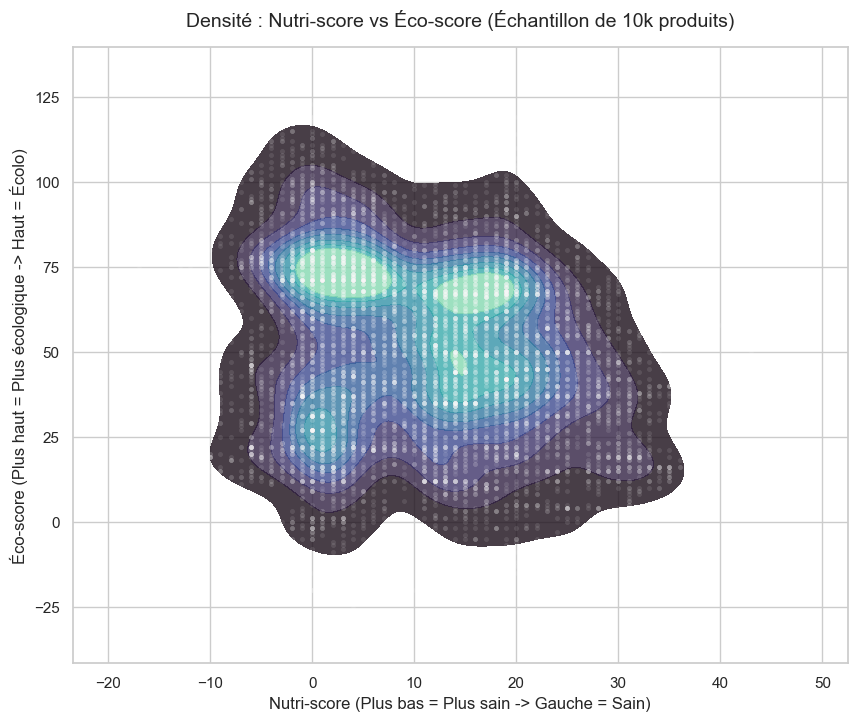

In [ ]:
if 'nutriscore_score' in df.columns and 'environmental_score_score' in df.columns:
    plt.figure(figsize=(10, 8))
    
    # Pour un KDEPlot propre, on sélectionne les points valides et on sample si nécessaire (10k points max)
    df_valid = df.dropna(subset=['nutriscore_score', 'environmental_score_score'])
    if len(df_valid) > 10000:
        df_sample = df_valid.sample(10000, random_state=42)
    else:
        df_sample = df_valid

    # Nuage de point couplé à une estimation de densité (KDE)
    # On trace les contours des densités majeures
    sns.kdeplot(
        data=df_sample, x='nutriscore_score', y='environmental_score_score',
        fill=True, cmap="mako", alpha=0.8
    )
    # On ajoute par-dessus le nuage de points légèrement transparent
    sns.scatterplot(
        data=df_sample, x='nutriscore_score', y='environmental_score_score', 
        s=10, color='white', alpha=0.1, edgecolor=None
    )
    
    plt.title("Densité : Nutri-score vs Éco-score (Échantillon de 10k produits)", fontsize=14, pad=15)
    plt.xlabel("Nutri-score (Plus bas = Plus sain -> Gauche = Sain)")
    plt.ylabel("Éco-score (Plus haut = Plus écologique -> Haut = Écolo)")
    
    plt.show()